In [22]:
%pip install pandas numpy scikit-learn matplotlib seaborn sentence-transformers

   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ---------------------------------------- 571.3/571.3 kB 2.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import  classification_report,accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sentence_transformers import SentenceTransformer

In [ ]:
df = pd.read_csv(r"C:\Users\Brindha Suvarna R\Desktop\spam-detection-nlp\data\processed\cleaned_spam_dataset.csv")

print(df.head())
print(df.columns)

   label                                               text source  \
0      0  Go until jurong point, crazy.. Available only ...    sms   
1      0                      Ok lar... Joking wif u oni...    sms   
2      1  Free entry in 2 a wkly comp to win FA Cup fina...    sms   
3      0  U dun say so early hor... U c already then say...    sms   
4      0  Nah I don't think he goes to usf, he lives aro...    sms   

   message_length  
0             111  
1              29  
2             155  
3              49  
4              61  
Index(['label', 'text', 'source', 'message_length'], dtype='str')


In [4]:
df.shape

(10052, 4)

In [5]:
df['label'].value_counts()

label
0    7948
1    2104
Name: count, dtype: int64

In [6]:
df['source'].value_counts()

source
sms      5158
email    4894
Name: count, dtype: int64

In [7]:
df = df.dropna()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "URL", text)
    text = re.sub(r"\d+", "NUM", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [8]:
# 🔥 Explicit Spam Pattern Features (INNOVATION)

df["has_link"] = df["text"].str.contains(r"http|www", regex=True).astype(int)

df["has_currency"] = df["text"].str.contains(r"₹|\$|£|€", regex=True).astype(int)

df["has_urgent_words"] = df["text"].str.contains(
    r"free|win|winner|urgent|offer|claim|prize|cash",
    case=False,
    regex=True
).astype(int)

# Optional (strong feature)
df["caps_ratio"] = df["text"].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)

In [9]:

# 🔹 TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(df['clean_text']).toarray()

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (10052, 5000)


In [10]:
def extract_metadata(text):
    return pd.Series({
        "length": len(text),
        "num_digits": sum(c.isdigit() for c in text),
        "num_upper": sum(c.isupper() for c in text),
        "num_special": len(re.findall(r'[!@#$%^&*(),.?":{}|<>]', text)),
        "num_urls": len(re.findall(r'http\S+', text)),
        "num_words": len(text.split())
    })

meta_features = df['text'].apply(extract_metadata)


df = pd.concat([df, meta_features], axis=1)

df.head()

,label,text,source,message_length,clean_text,has_link,has_currency,has_urgent_words,caps_ratio,length,num_digits,num_upper,num_special,num_urls,num_words
0,0,"Go until jurong point, crazy.. Available only ...",sms,111,go until jurong point crazy available only in ...,0,0,0,0.027027,111,0,3,9,0,20
1,0,Ok lar... Joking wif u oni...,sms,29,ok lar joking wif u oni,0,0,0,0.068966,29,0,2,6,0,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,sms,155,free entry in NUM a wkly comp to win fa cup fi...,0,0,1,0.064516,155,25,10,4,0,28
3,0,U dun say so early hor... U c already then say...,sms,49,u dun say so early hor u c already then say,0,0,0,0.040816,49,0,2,6,0,11
4,0,"Nah I don't think he goes to usf, he lives aro...",sms,61,nah i dont think he goes to usf he lives aroun...,0,0,0,0.032787,61,0,2,1,0,13


In [11]:
# Encode source (sms/email) → cross-domain feature
df['source_encoded'] = df['source'].map({'sms': 0, 'email': 1})

C:\Users\Brindha Suvarna R\AppData\Local\Temp\ipykernel_9208\173578007.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_name', data=df, palette=palette)


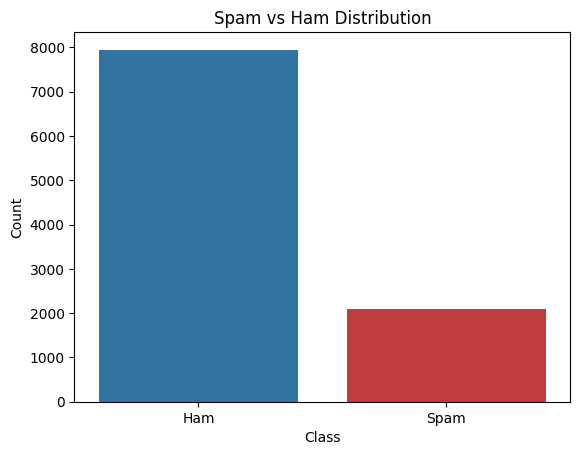

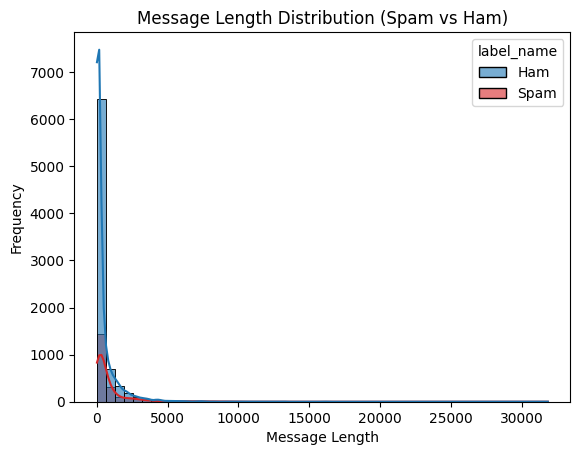

In [12]:
# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Define clean labels
df['label_name'] = df['label'].map({0: 'Ham', 1: 'Spam'})

# Define color palette (IEEE-friendly)
palette = {'Ham': '#1f77b4', 'Spam': '#d62728'}  # blue & red

# Count plot
sns.countplot(x='label_name', data=df, palette=palette)
plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


# Histogram with proper separation
sns.histplot(
    data=df,
    x='message_length',
    hue='label_name',
    kde=True,
    bins=50,
    palette=palette,
    alpha=0.6   # 🔥 important to avoid overlap hiding
)

plt.title("Message Length Distribution (Spam vs Ham)")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

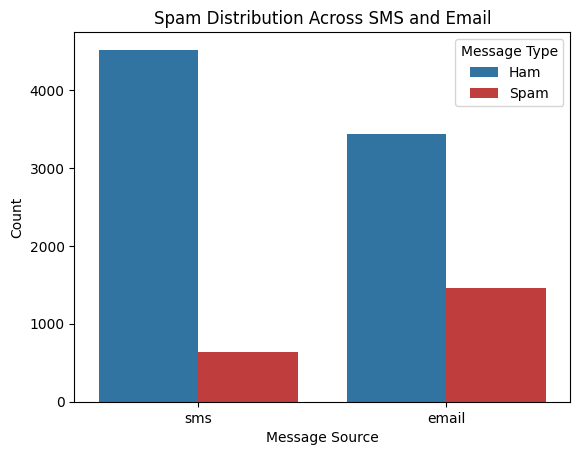

In [13]:
# Define IEEE-friendly palette
palette = {'Ham': '#1f77b4', 'Spam': '#d62728'}

sns.countplot(
    x='source',
    hue='label_name',
    data=df,
    palette=palette
)

plt.title("Spam Distribution Across SMS and Email")
plt.xlabel("Message Source")
plt.ylabel("Count")
plt.legend(title="Message Type")

plt.show()

In [14]:
model = SentenceTransformer('all-MiniLM-L6-v2')

text_embeddings = model.encode(df['clean_text'].tolist(), show_progress_bar=True)

text_embeddings = np.array(text_embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/315 [00:00<?, ?it/s]

In [15]:
np.save(r"C:\Users\Brindha Suvarna R\Desktop\spam-detection-nlp\reports\results\text_embeddings.npy", text_embeddings)

In [16]:
X_text = text_embeddings

In [17]:
X_meta = df[[
    'length',
    'num_digits',
    'num_upper',
    'num_special',
    'num_urls',
    'num_words',
    'source_encoded',
    'has_link',
    'has_currency',
    'has_urgent_words',
    'caps_ratio'
]]

In [18]:
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

X_hybrid = np.hstack((text_embeddings, X_meta_scaled))

y = df['label'].values

In [19]:
# Create ONE split using indices
X_train_idx, X_test_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42
)

# Apply SAME split everywhere
X_train_tf, X_test_tf = X_tfidf[X_train_idx], X_tfidf[X_test_idx]
X_train_t, X_test_t = X_text[X_train_idx], X_text[X_test_idx]
X_train_m, X_test_m = X_meta_scaled[X_train_idx], X_meta_scaled[X_test_idx]
X_train_h, X_test_h = X_hybrid[X_train_idx], X_hybrid[X_test_idx]

y_train, y_test = y[X_train_idx], y[X_test_idx]

In [20]:

def train_and_evaluate_models(X_train, X_test, y_train, y_test, feature_name):

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM": LinearSVC(),
        "XGBoost": XGBClassifier(eval_metric='logloss')
    }

    results = []

    best_model = None
    best_f1 = 0
    best_preds = None
    best_model_obj = None

    for name, model in models.items():

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        precision = precision_score(y_test, preds)
        recall = recall_score(y_test, preds)

        # Store all metrics
        results.append({
            "Feature Set": feature_name,
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4)
        })

        # Track best model (based on F1)
        if f1 > best_f1:
            best_f1 = f1
            best_model = name
            best_preds = preds
            best_model_obj = model 

    return results, best_model, best_f1, best_preds,best_model_obj



In [21]:
# 🔹 Train all feature sets

results_tfidf = train_and_evaluate_models(
    X_train_tf, X_test_tf, y_train, y_test, "TF-IDF Baseline"
)

results_text = train_and_evaluate_models(
    X_train_t, X_test_t, y_train, y_test, "Text Only"
)

results_meta = train_and_evaluate_models(
    X_train_m, X_test_m, y_train, y_test, "Metadata Only"
)

results_hybrid = train_and_evaluate_models(
    X_train_h, X_test_h, y_train, y_test, "Hybrid Model"
)

In [22]:
res_tfidf, best_model_tf, best_f1_tf, preds_tf, model_tf = results_tfidf
res_text, best_model_t, best_f1_t, preds_t, model_text = results_text
res_meta, best_model_m, best_f1_m, preds_m, model_meta = results_meta
res_hybrid, best_model_h, best_f1_h, preds_h, hybrid_model = results_hybrid

In [23]:
df_results = pd.DataFrame(
    res_tfidf + res_text + res_meta + res_hybrid
)

print(df_results)

        Feature Set                Model  Accuracy  Precision  Recall  \
0   TF-IDF Baseline  Logistic Regression    0.9567     0.9591  0.8180   
1   TF-IDF Baseline        Random Forest    0.9722     0.9675  0.8903   
2   TF-IDF Baseline                  SVM    0.9736     0.9579  0.9077   
3   TF-IDF Baseline              XGBoost    0.9751     0.9443  0.9302   
4         Text Only  Logistic Regression    0.9478     0.9088  0.8204   
5         Text Only        Random Forest    0.9199     0.9959  0.6010   
6         Text Only                  SVM    0.9587     0.8995  0.8928   
7         Text Only              XGBoost    0.9602     0.9350  0.8603   
8     Metadata Only  Logistic Regression    0.8553     0.7371  0.4264   
9     Metadata Only        Random Forest    0.9145     0.8086  0.7481   
10    Metadata Only                  SVM    0.8528     0.7333  0.4115   
11    Metadata Only              XGBoost    0.9189     0.8216  0.7581   
12     Hybrid Model  Logistic Regression    0.9552 

In [24]:
df_results['Best Model'] = (
    ((df_results['Feature Set'] == "TF-IDF Baseline") & (df_results['Model'] == best_model_tf)) |
    ((df_results['Feature Set'] == "Text Only") & (df_results['Model'] == best_model_t)) |
    ((df_results['Feature Set'] == "Metadata Only") & (df_results['Model'] == best_model_m)) |
    ((df_results['Feature Set'] == "Hybrid Model") & (df_results['Model'] == best_model_h))
)

In [25]:
print("\n🔹 Best Models Summary:")
print(f"TF-IDF → {best_model_tf} (F1 = {best_f1_tf:.4f})")
print(f"Text Only → {best_model_t} (F1 = {best_f1_t:.4f})")
print(f"Metadata Only → {best_model_m} (F1 = {best_f1_m:.4f})")
print(f"Hybrid Model → {best_model_h} (F1 = {best_f1_h:.4f})")


🔹 Best Models Summary:
TF-IDF → XGBoost (F1 = 0.9372)
Text Only → SVM (F1 = 0.8961)
Metadata Only → XGBoost (F1 = 0.7886)
Hybrid Model → XGBoost (F1 = 0.9320)


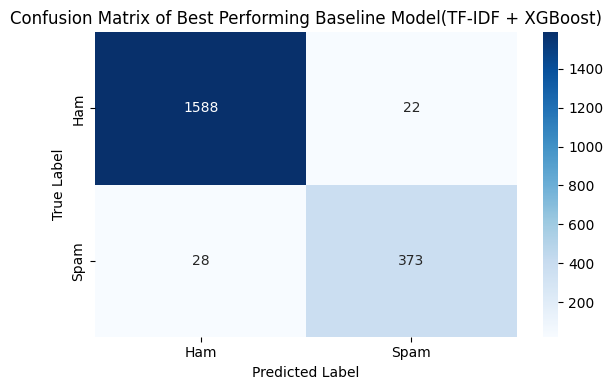

In [26]:

# =========================
# Predictions for TF-IDF model
# =========================
# Assuming you already trained:
# X_train_tf, X_test_tf, y_train, y_test

tfidf_model = XGBClassifier(eval_metric='logloss')
tfidf_model.fit(X_train_tf, y_train)

y_pred_tfidf = tfidf_model.predict(X_test_tf)

# =========================
# Confusion Matrix
# =========================
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Confusion Matrix of Best Performing Baseline Model(TF-IDF + XGBoost)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

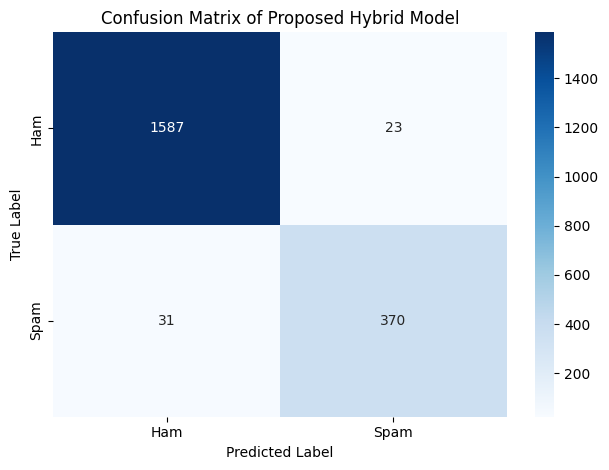

In [27]:
# Compute confusion matrix
cm = confusion_matrix(y_test, preds_h)

# Plot
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Confusion Matrix of Proposed Hybrid Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

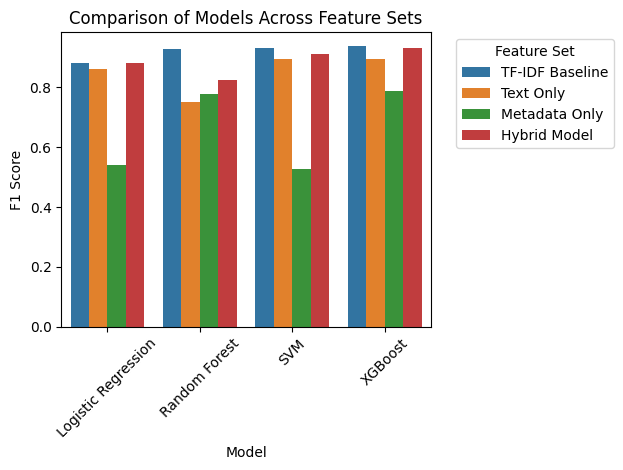

In [28]:
sns.barplot(data=df_results, x="Model", y="F1 Score", hue="Feature Set")

plt.title("Comparison of Models Across Feature Sets")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)

plt.legend(title="Feature Set", bbox_to_anchor=(1.05, 1), loc='upper left')  # 🔥 fix

plt.tight_layout()
plt.show()

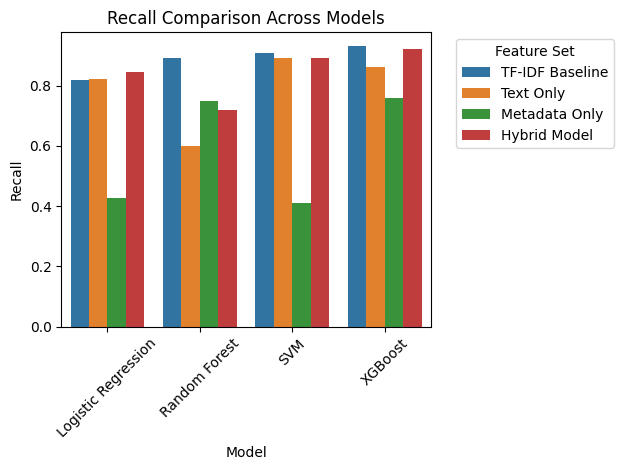

In [29]:
sns.barplot(data=df_results, x="Model", y="Recall", hue="Feature Set")

plt.title("Recall Comparison Across Models")
plt.ylabel("Recall")
plt.xticks(rotation=45)

# Move legend outside (clean look)
plt.legend(title="Feature Set", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [30]:
# Get indices of test set
test_indices = X_test_idx

In [31]:
# Convert to numpy arrays
y_true = y_test
y_pred = preds_h

# False Positives: Ham (0) → predicted Spam (1)
false_positives = np.where((y_true == 0) & (y_pred == 1))[0]

# False Negatives: Spam (1) → predicted Ham (0)
false_negatives = np.where((y_true == 1) & (y_pred == 0))[0]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 23
False Negatives: 31


In [32]:
# Map back to original dataframe indices
fp_indices = test_indices[false_positives]
fn_indices = test_indices[false_negatives]

print("\n🔴 False Positives (Ham classified as Spam):\n")
for i in fp_indices[:5]:   # show 5 examples
    print("Message:", df.loc[i, 'text'])
    print("Actual: Ham | Predicted: Spam\n")

print("\n🔵 False Negatives (Spam classified as Ham):\n")
for i in fn_indices[:5]:
    print("Message:", df.loc[i, 'text'])
    print("Actual: Spam | Predicted: Ham\n")


🔴 False Positives (Ham classified as Spam):

Message: MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*
Actual: Ham | Predicted: Spam

Message: Subject: find the perfect vacation package dear daren farmer , it ' s time to take a break , go somewhere wild and fantastic , and make all your travel plans happen in one place . expedia . com has some great packages for you that include air , hotel , and in some cases a car . just pick your destination , the month you want to leave , and we ' ll show you everything that ' s available . look for the yellow star to find packages with the greatest value . http : / / www . expedia . com / daily / packages / also , did you get your free copy of expedia travels magazine yet ? the premiere edition is packed with information that will show you how to use the web to travel smarter . get your free copy today ! ode = adt bahamas cruise with nascar heroes meet some of the top nascar drivers on this four - night cruise to the bahamas from port canavera

In [34]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import shap

In [34]:
feature_names = (
    [f"bert_{i}" for i in range(text_embeddings.shape[1])] +
    list(X_meta.columns)
)

In [35]:
X_test_h_df = pd.DataFrame(X_test_h, columns=feature_names)

In [36]:

explainer = shap.TreeExplainer(hybrid_model)

shap_values = explainer.shap_values(X_test_h_df.iloc[:500])

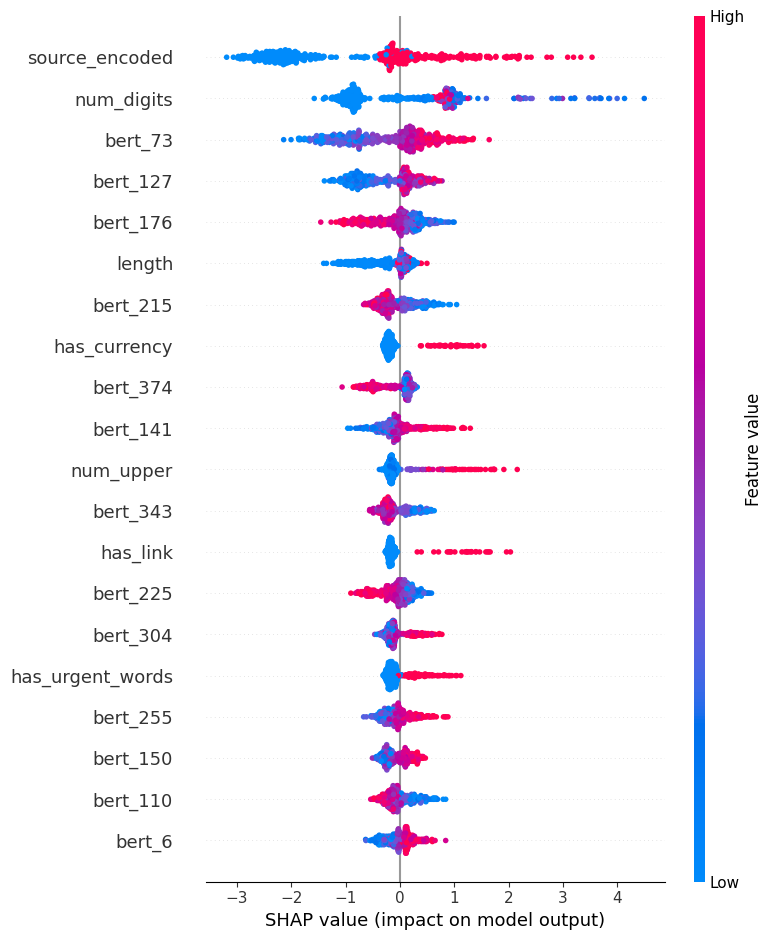

In [37]:
shap.summary_plot(shap_values, X_test_h_df.iloc[:500], feature_names=feature_names)

In [39]:
import pickle

with open(r"C:\Users\Brindha Suvarna R\Desktop\spam-detection-nlp\spam-web-app\model\hybrid_model.pkl", "wb") as f:
    pickle.dump(hybrid_model, f)

with open(r"C:\Users\Brindha Suvarna R\Desktop\spam-detection-nlp\spam-web-app\model\scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)